In [1]:
import os
HOME = os.getcwd()

In [2]:
!pip install roboflow --quiet

my_api_key = "2ADHAstu11Caf1RzRFSf"
my_workspace = "daniele-russo"
my_project = "text-and-drive-yolov8"
my_version = 1

from roboflow import Roboflow
rf = Roboflow(api_key=my_api_key)
project = rf.workspace(my_workspace).project(my_project)
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Text-and-Drive-YoloV8-1 in yolov8:: 100%|██████████| 3820/3820 [00:00<00:00, 9146.67it/s]


In [3]:
VERSION = my_version

Alternativamente, è possibile importare il dataset a partire da un file .zip

## Ultralytics e Yolo

Ultralytics è un'azienda specializzata nello sviluppo di software per la computer vision e l'apprendimento automatico.

YoloV8 è l'ultima versione di YOLO sviluppata da Ultralytics (dettagli sulla sua architettura possono essere visionati qui https://blog.roboflow.com/whats-new-in-yolov8/#the-yolov8-annotation-format). È possibile utilizzarla attraverso l'utilizzo di una comodissima CLI. La versione di Ultralytics di YoloV8 è a disposizione in licenza *GNU Affero General Public License v3.0* per progetti accademici e open source (https://ultralytics.com/license)

<img src="https://raw.githubusercontent.com/ultralytics/assets/main/yolov8/yolo-comparison-plots.png" width="500px" />
<figcaption>Grafico di confronto tra le varie versioni di YOLO</figcaption>

La CLI ci permette di scegliere tra diversi task:
- Detect: Per problemi di object detection
- Segment: Per problemi di object segmentation.
- Classify: Per la classificazione in label di un'immagine.
- Pose: Per identificare gli oggetti e stimare i suoi *keypoints*.

In [4]:
# Pip install method (recommended)

%pip install ultralytics

from IPython import display
display.clear_output()
from IPython.display import display, Image

import ultralytics
ultralytics.checks()

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [5]:
# Training sul nostro dataset custom di immagini 640x640 facendo transfer learning
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=640 plots=True

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Text-and-Drive-YoloV8-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=F

/content


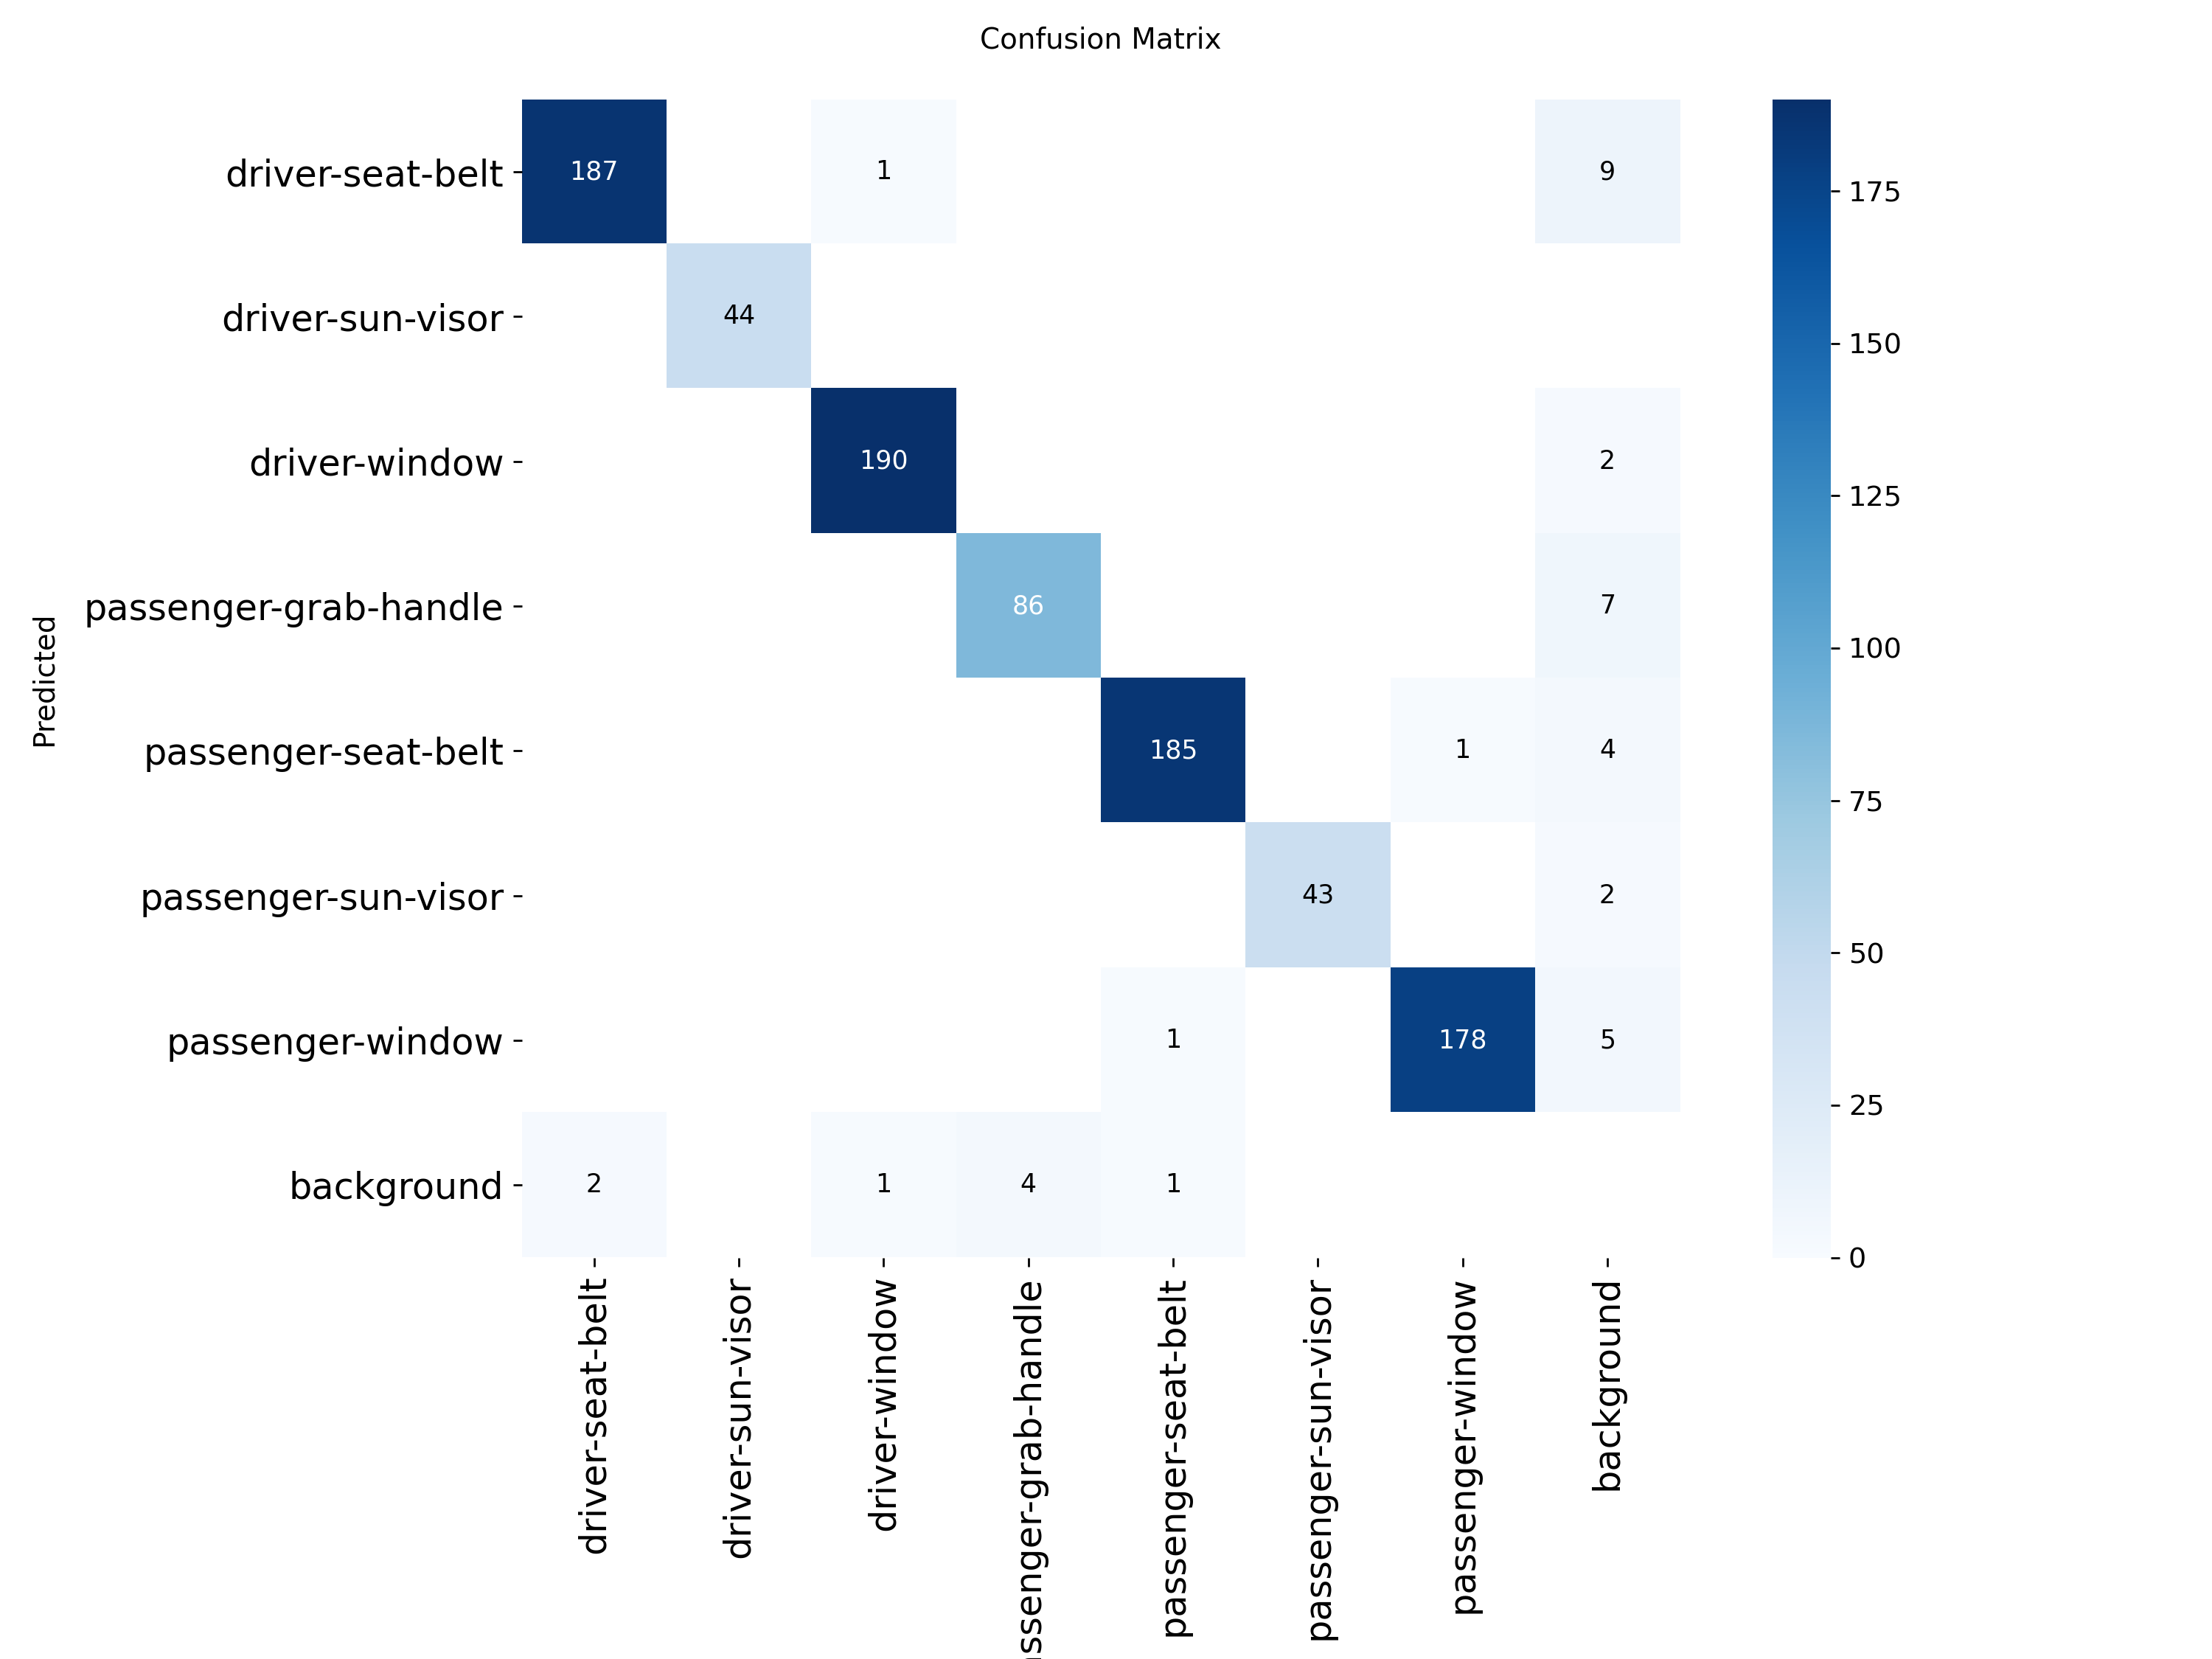

In [7]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


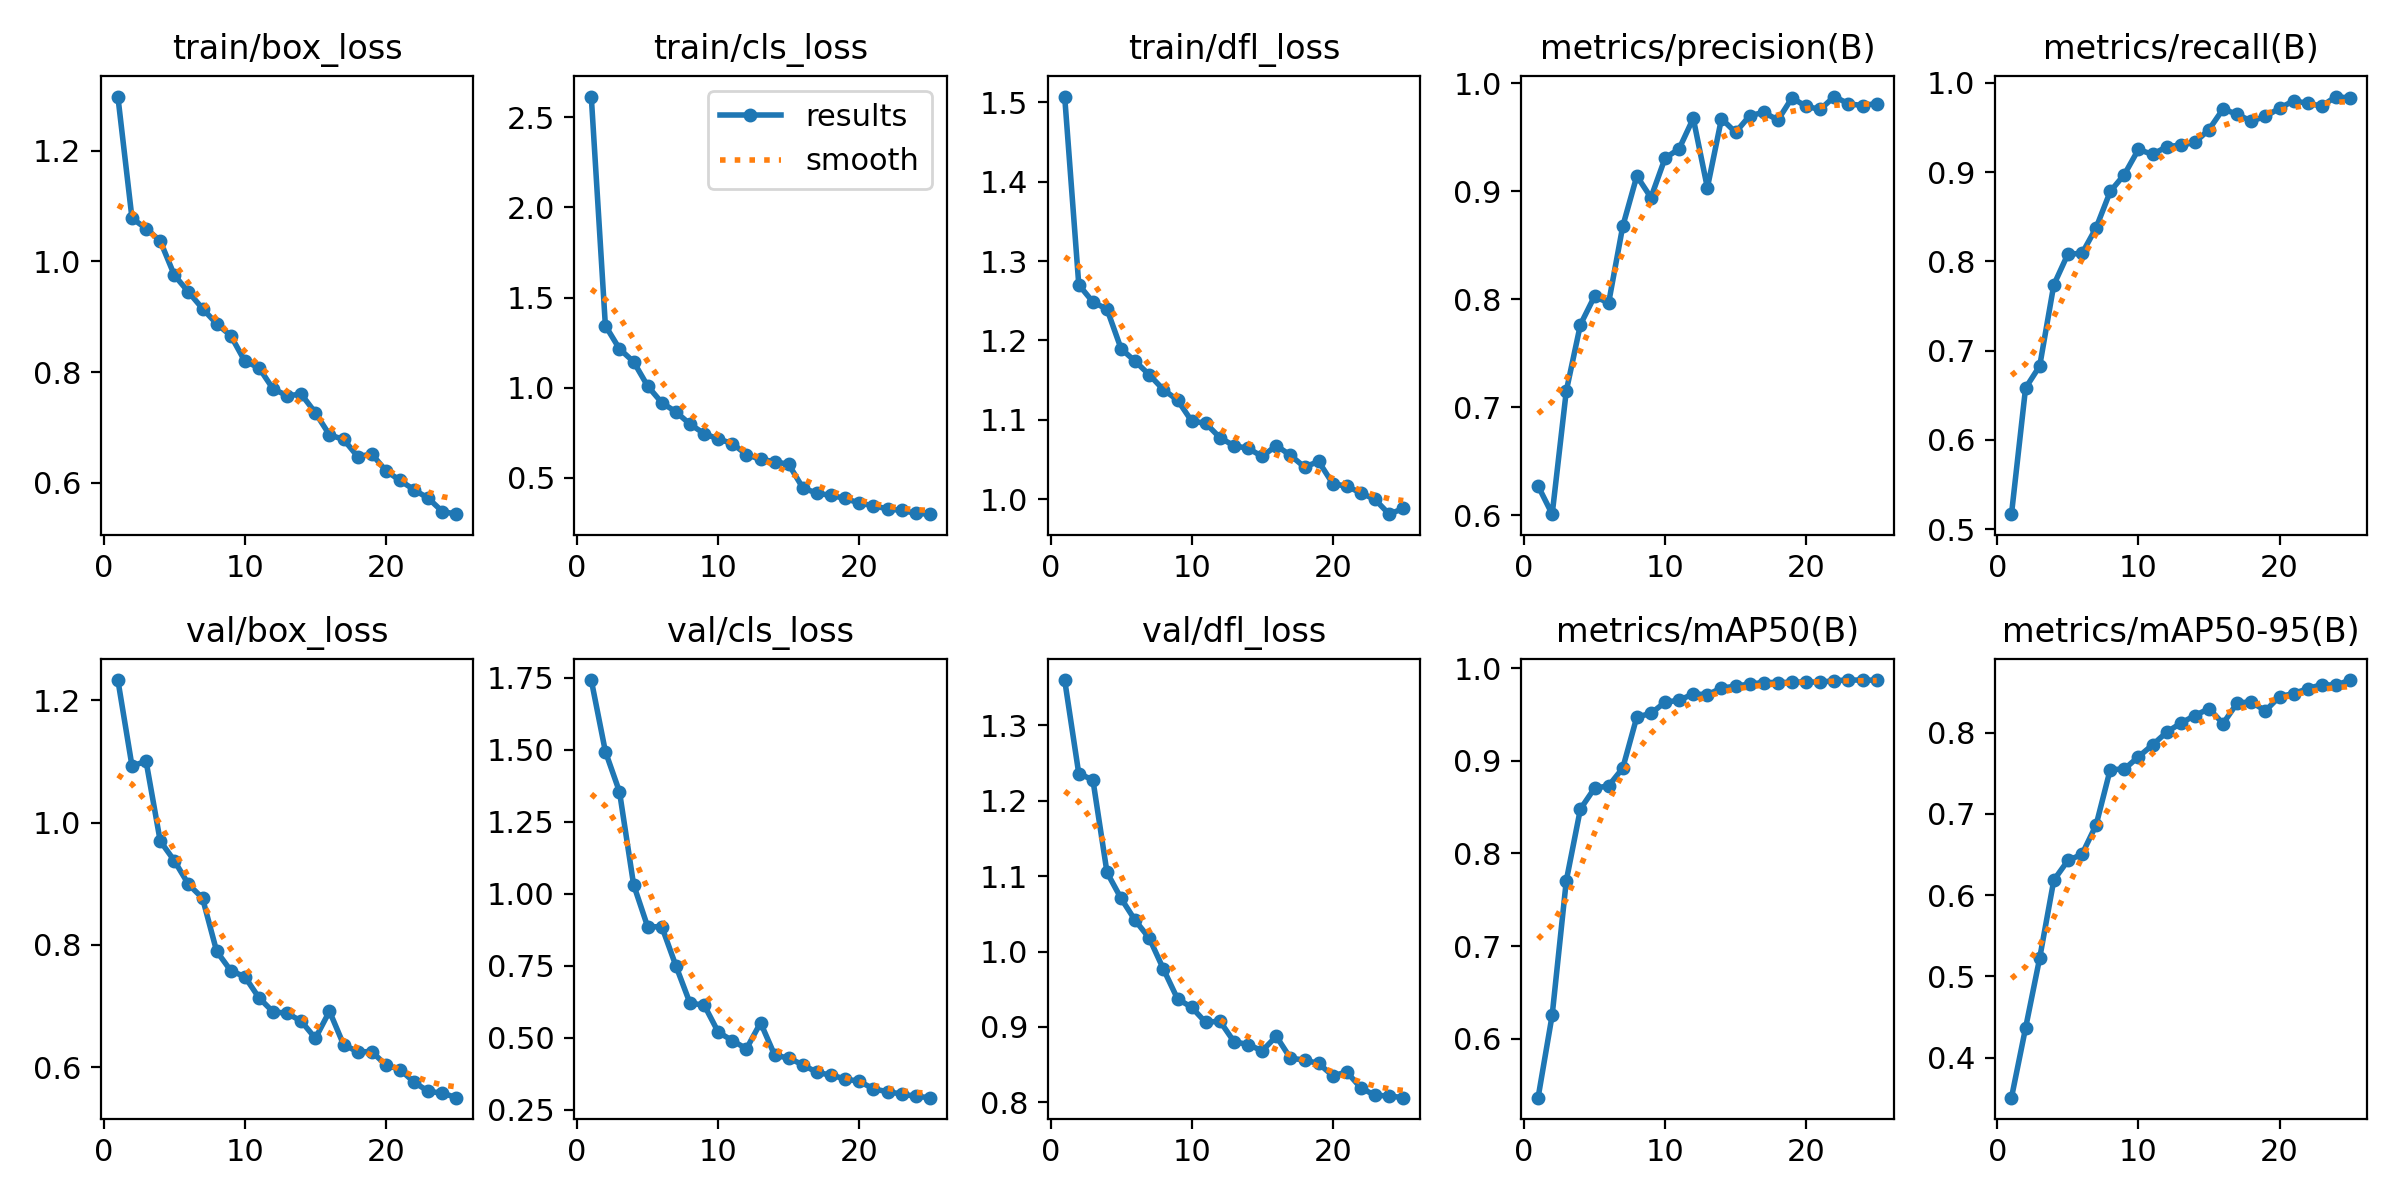

In [8]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


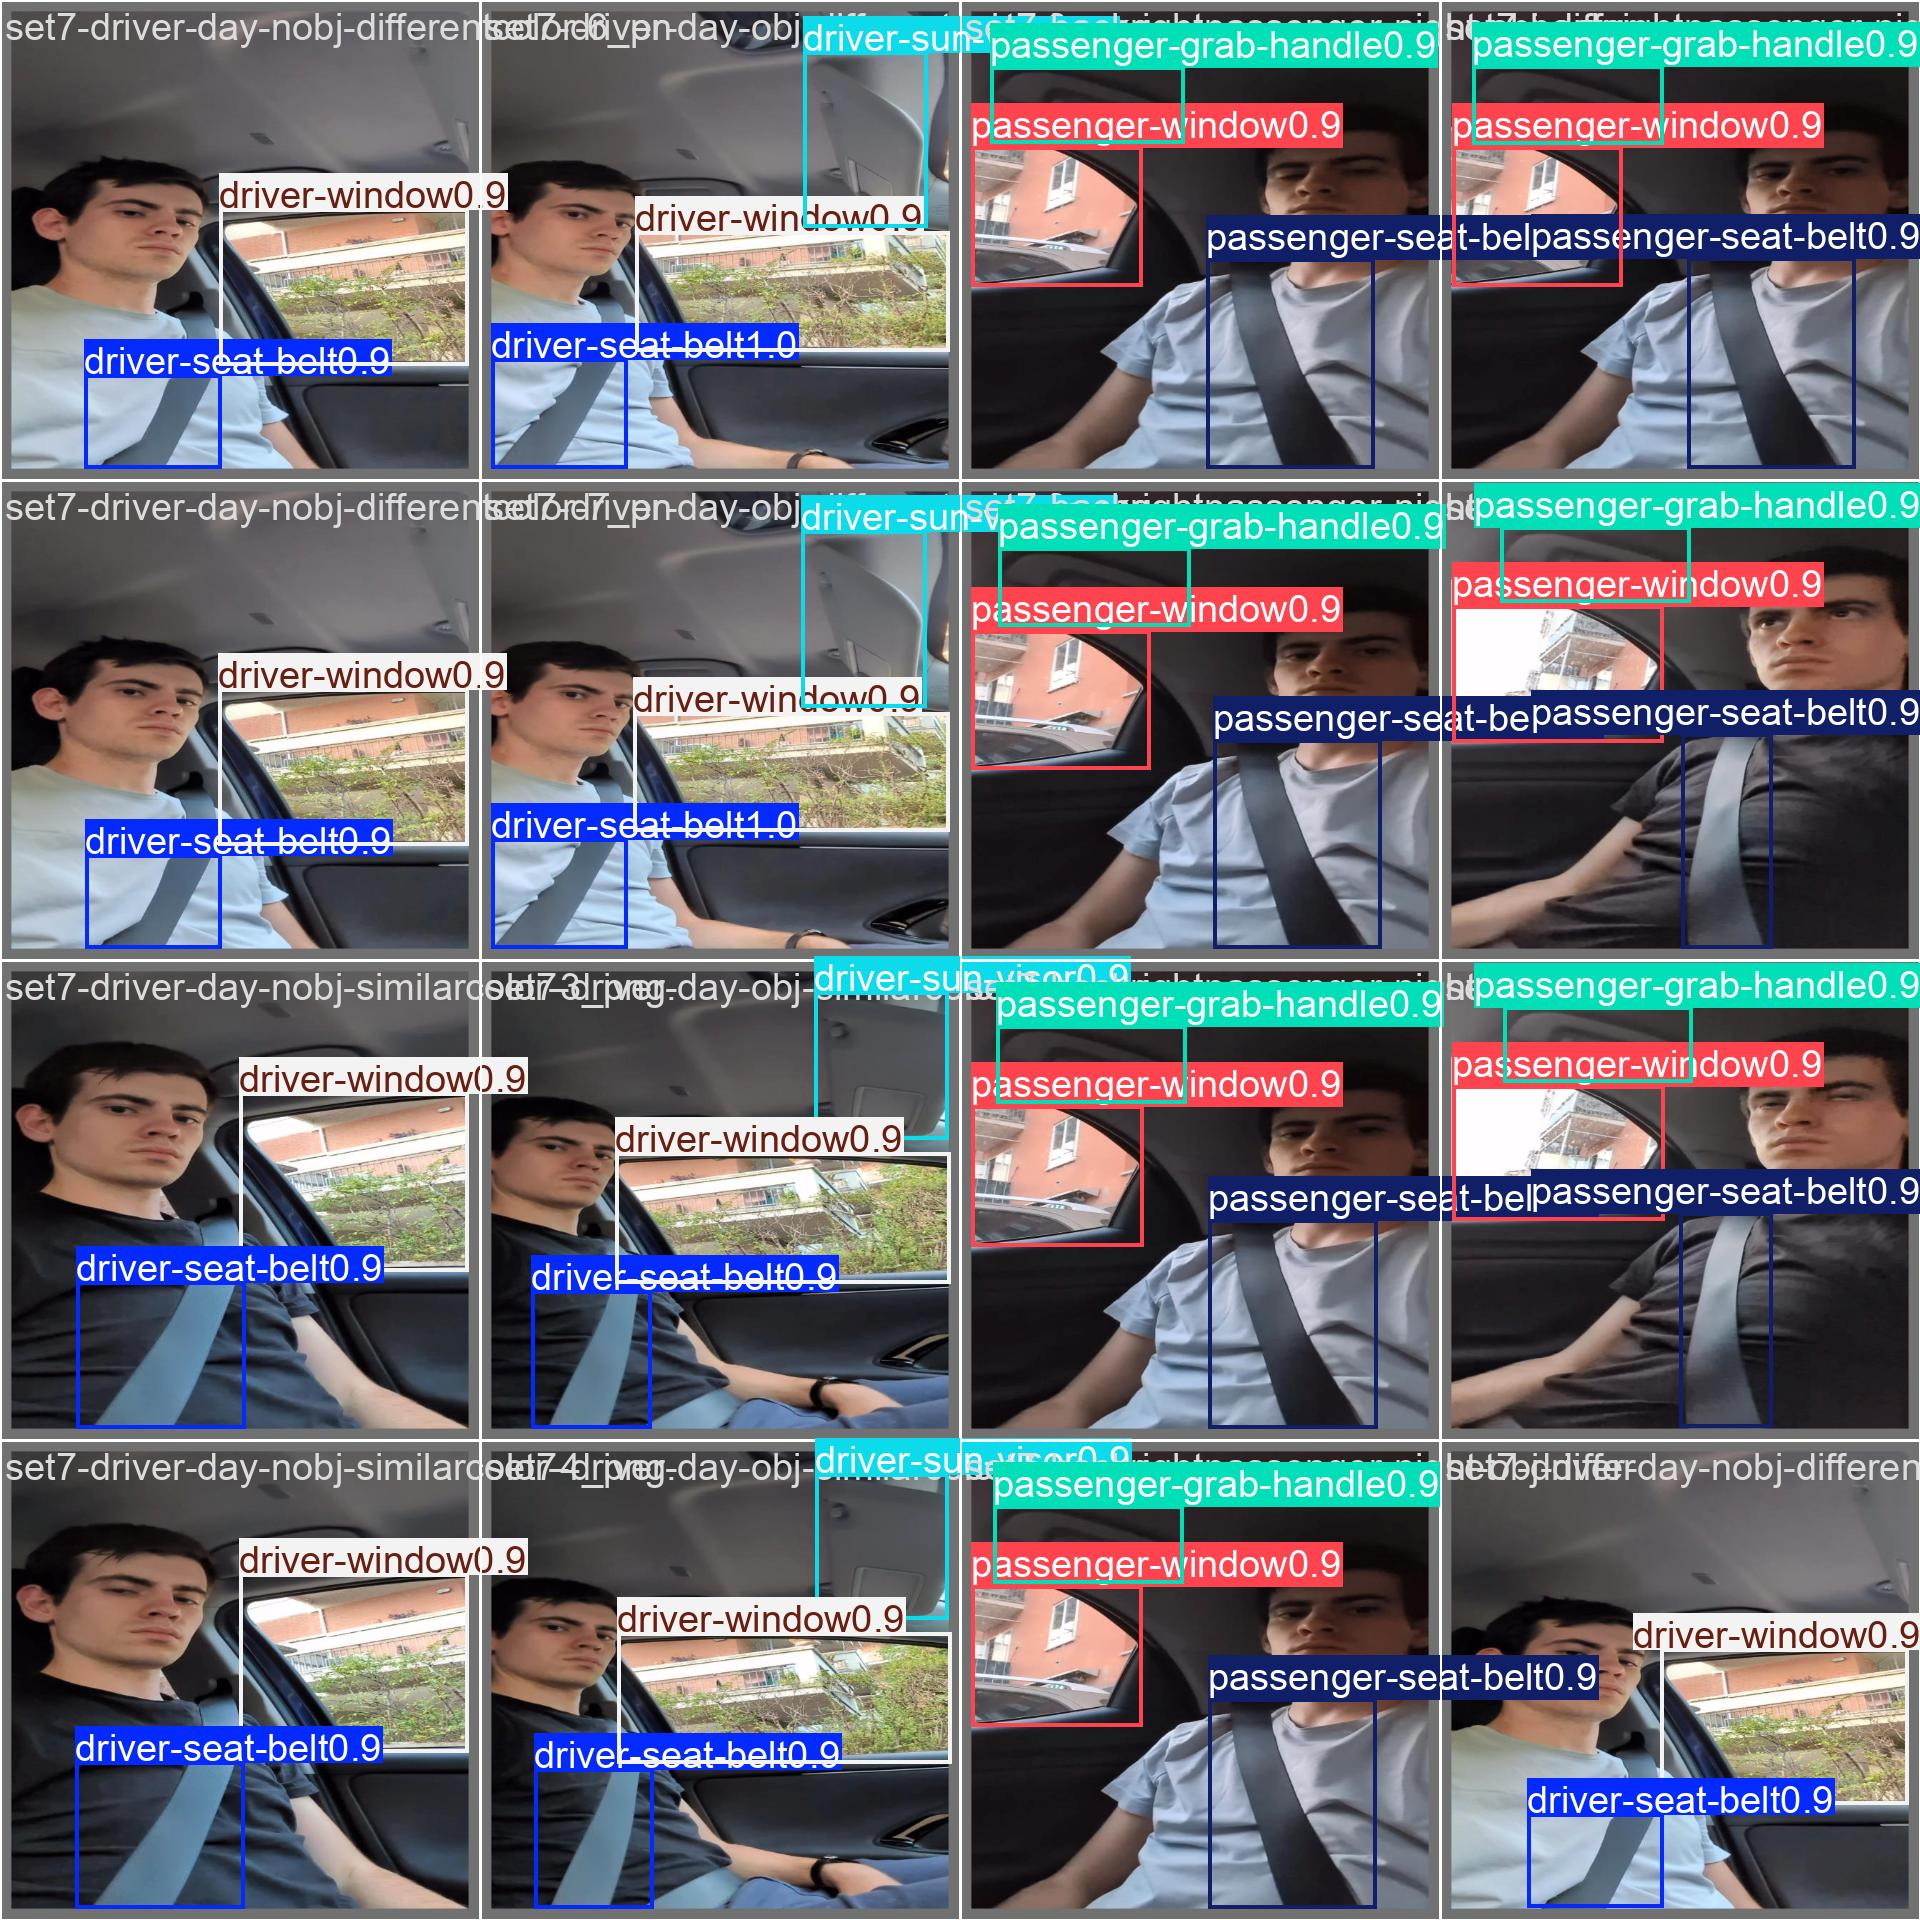

In [9]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [12]:
%cd {HOME}
# Validation dataset
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data=Text-and-Drive-YoloV8-1/data.yaml

/content
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1454.7±333.3 MB/s, size: 29.7 KB)
val: Scanning /content/Text-and-Drive-YoloV8-1/valid/labels.cache... 381 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 381/381 66.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.5it/s 6.9s
                   all        381        924      0.981      0.983      0.987      0.865
      driver-seat-belt        189        189      0.984      0.984      0.991       0.81
      driver-sun-visor         44         44       0.99          1      0.995      0.866
         driver-window        191        192      0.991      0.984      0.985      0.909
 passenger-grab-handle         90         90      0.966      0.939      0.972      0.833
   passenger-seat-bel

/content


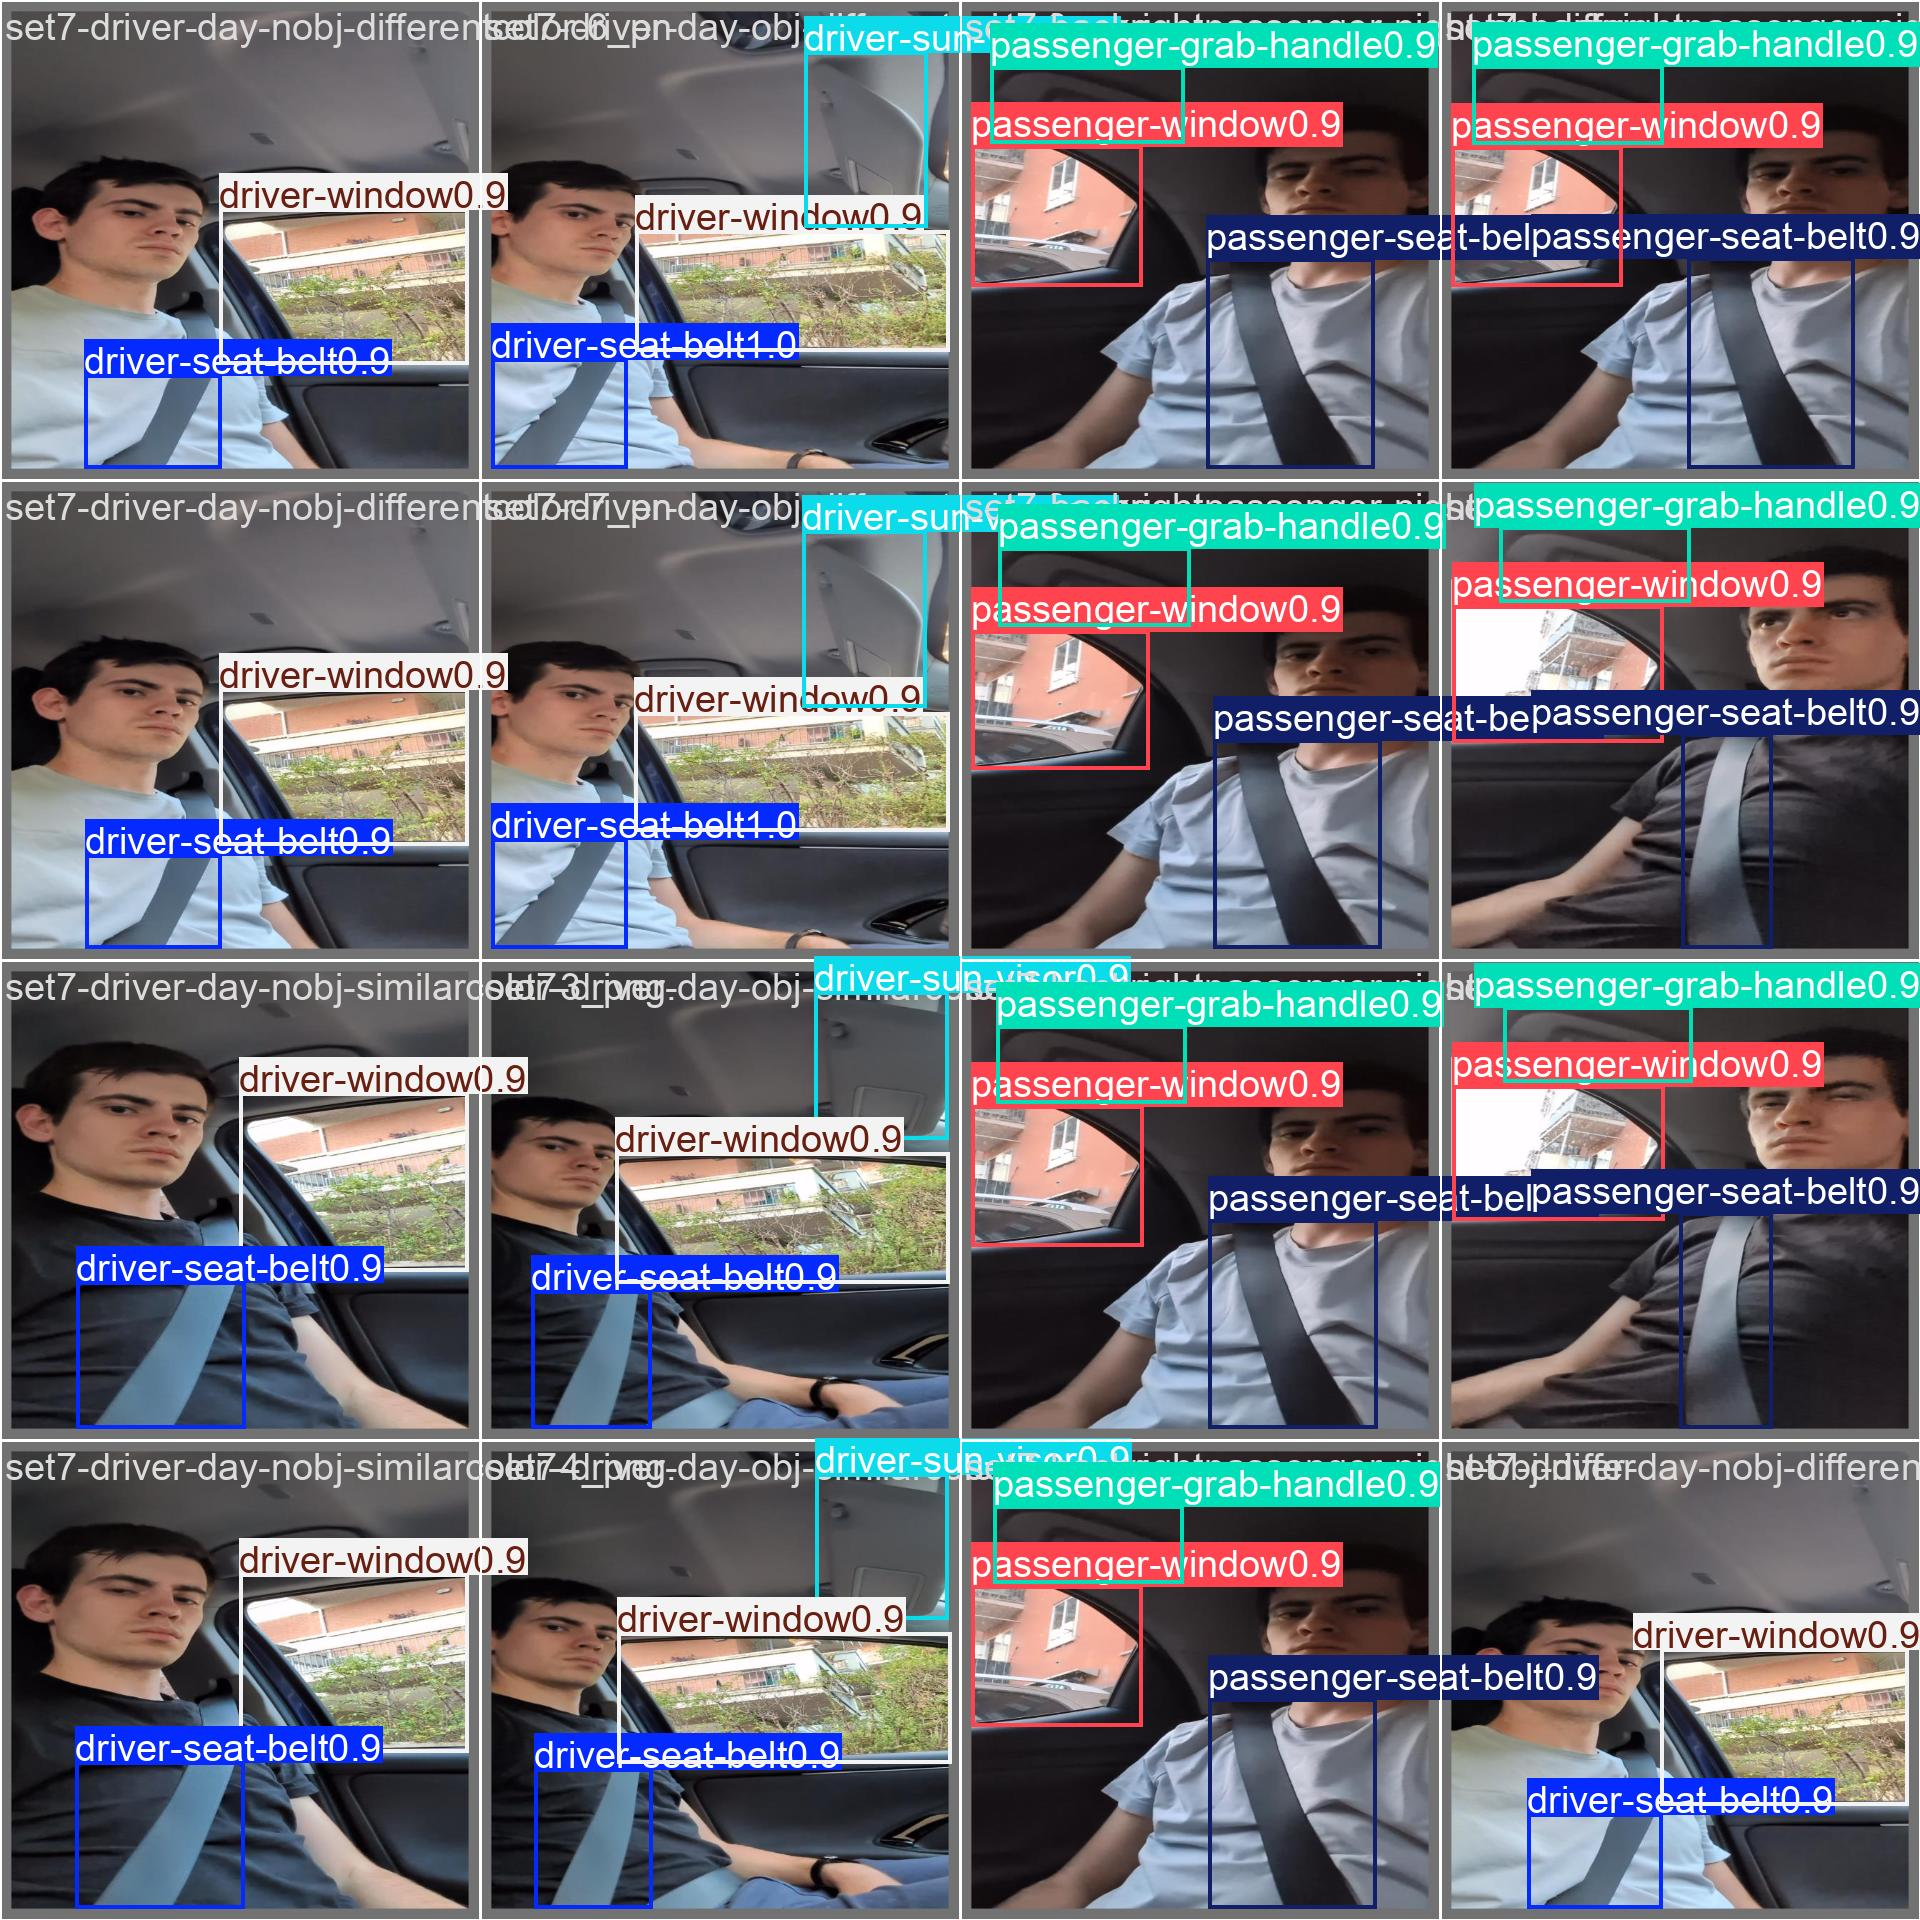

In [14]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/val-2/val_batch0_pred.jpg', width=600)

/content


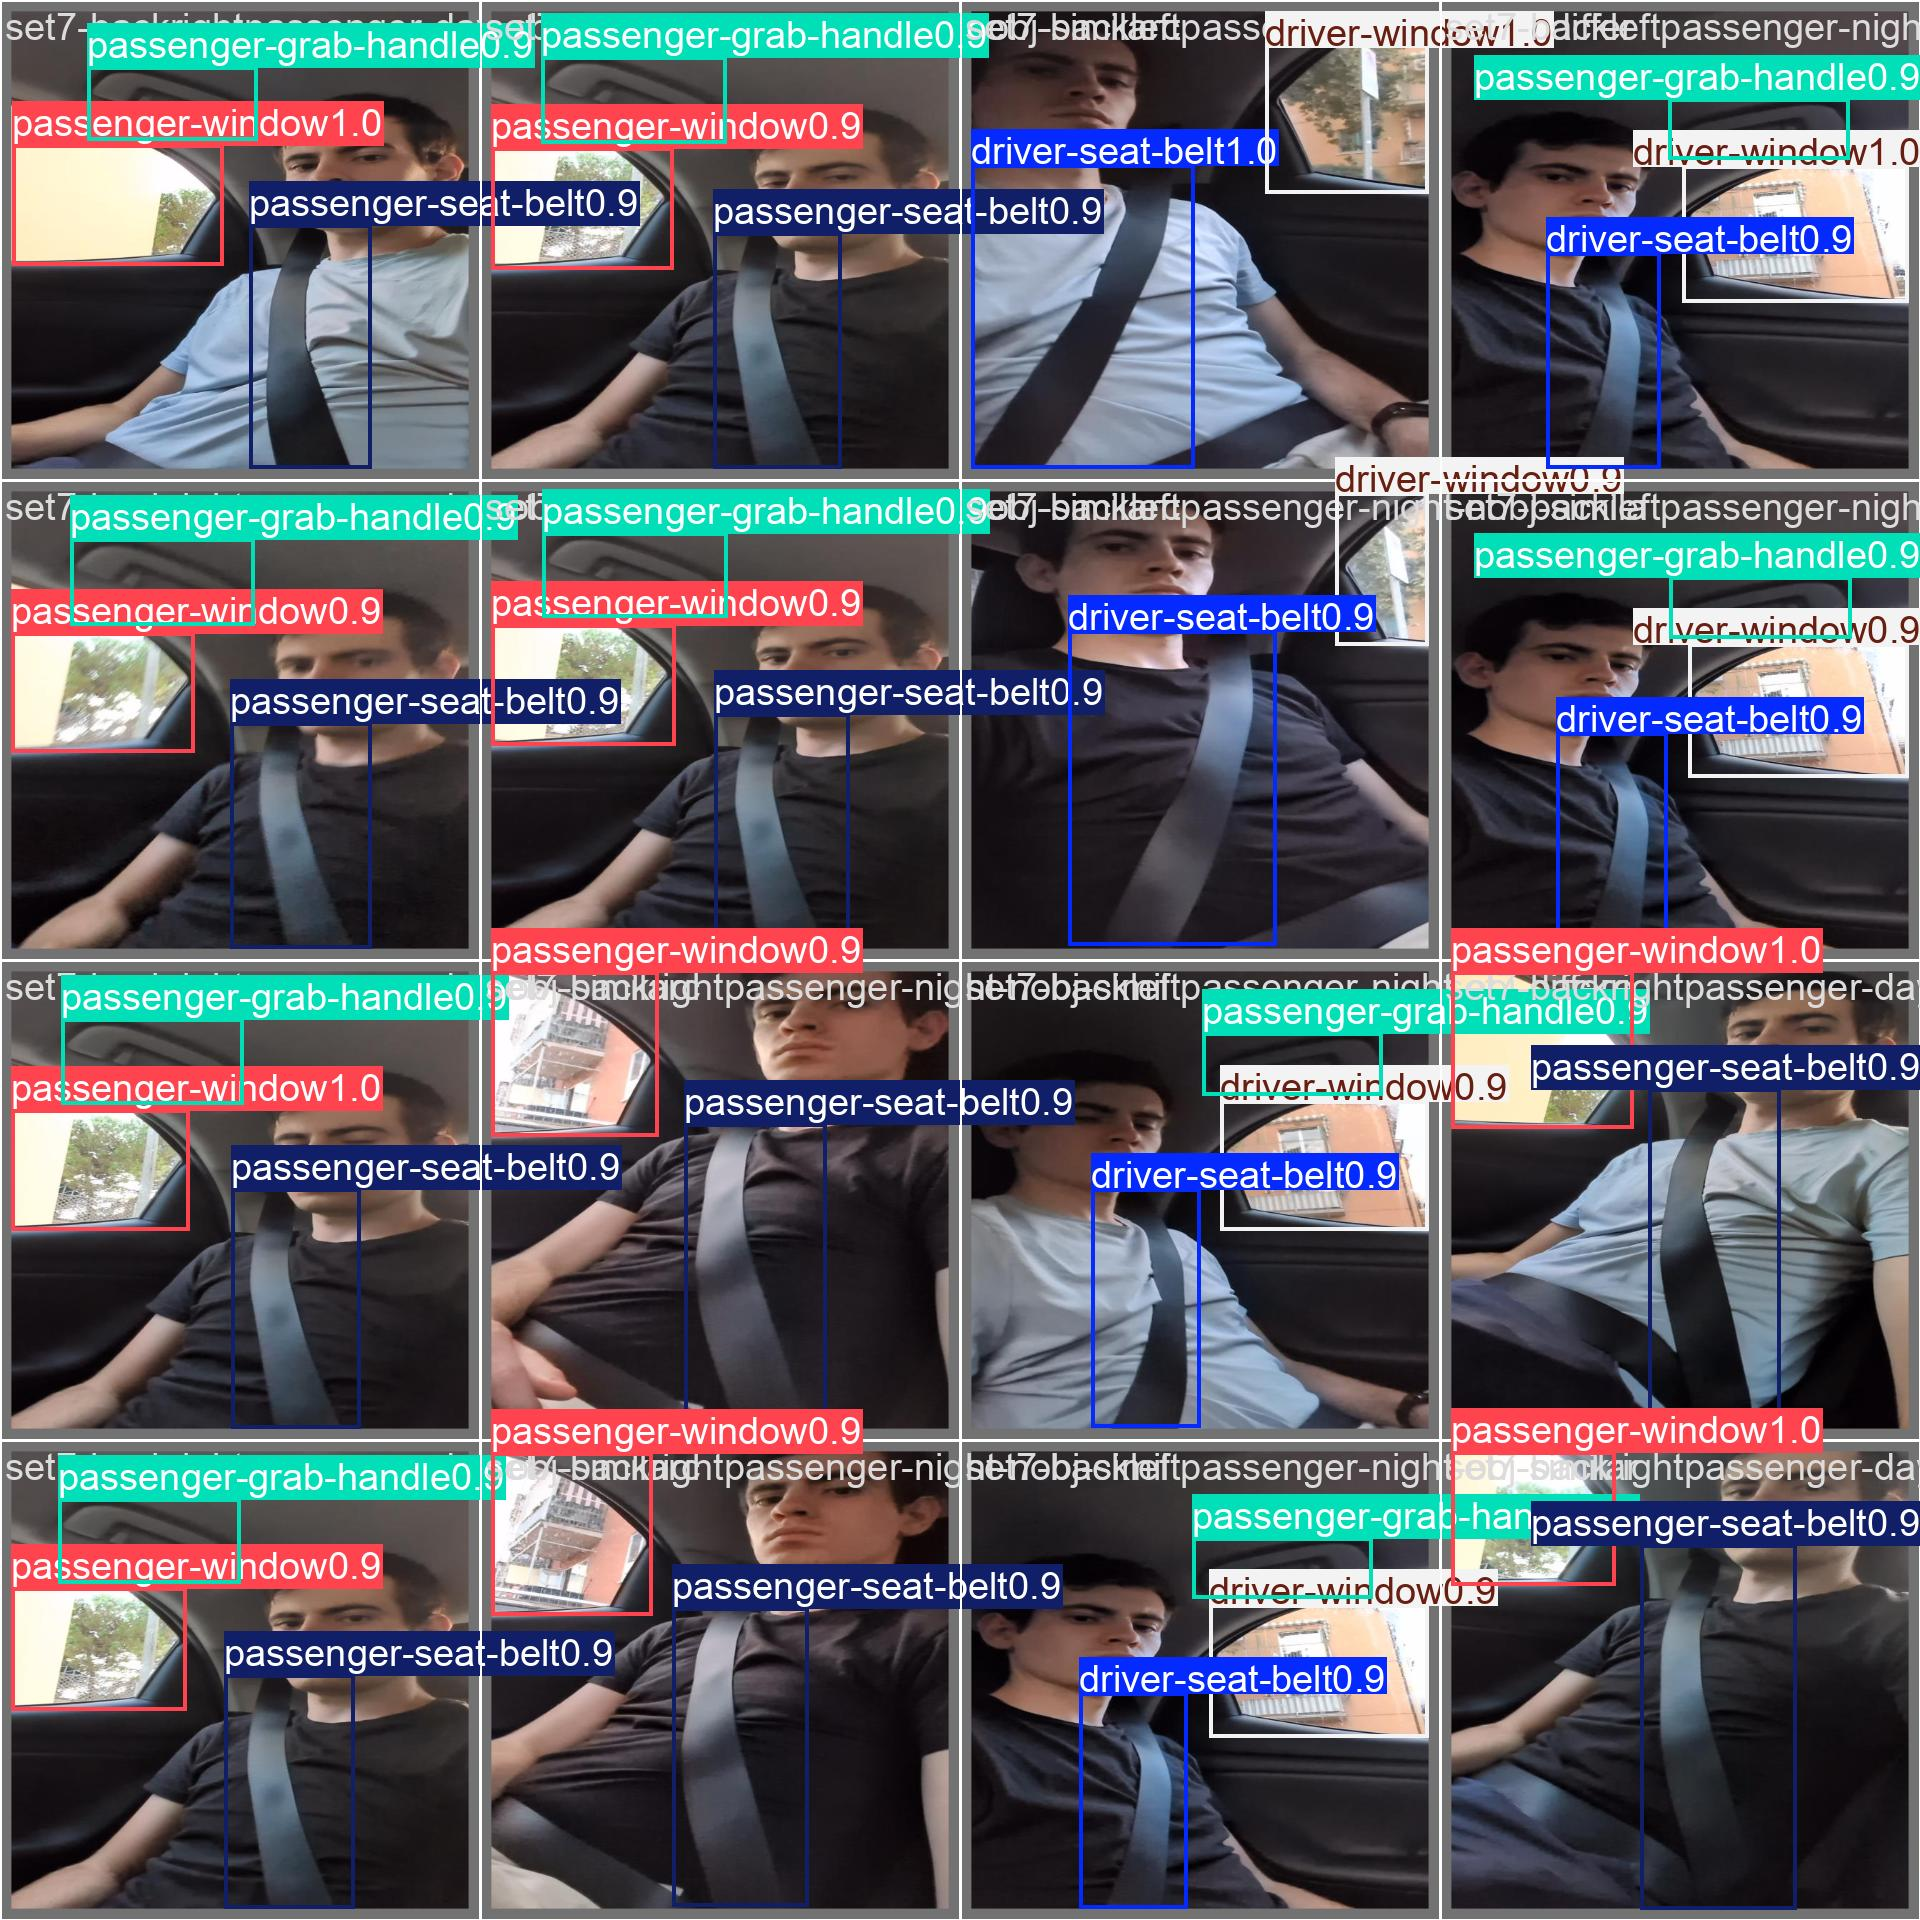

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/val-2/val_batch1_pred.jpg', width=600)

***scommentare le righe di codice se lo si vuole salvare***

# Salvare il modello ottenuto
Possiamo salvare i pesi del modello appena allenato nel nostro google drive (link della cartella condivisa con tutti i pesi https://drive.google.com/drive/folders/1C_gbs3u8XcdAeOGImWvidZHj7BTpTDcH?usp=sharing), in questo modo possiamo fare a meno di utilizzare la inference API di Roboflow e possiamo lavorare direttamente con la CLI ```yolo TASK MODE ARGS``` (più dettagli su https://docs.ultralytics.com/usage/cli)

Per salvare i pesi della rete ho deciso di utilizzare la seguente convenzione:

```weights_YYYY-MM-DD_H-M-S.pt```

che identificano univocamente i pesi del modello appena allenato, in particolare:
- YYYY è l'anno
- MM è il mese
- DD è il giorno
- H è l'ora
- M sono i minuti
- S sono i secondi

In [22]:
from datetime import datetime

# oggetto che contiene la data e l'ora corrente
now = datetime.now()

# YY-mm-dd_H:M:S
dt_string = now.strftime("%Y-%m-%d_%H-%M-%S")

from google.colab import drive
drive.mount('/content/gdrive')

!cp {HOME}/runs/detect/train/weights/best.pt {HOME}/gdrive/"My Drive"/tesi/pretrained-weights-{dt_string}.pt
drive.flush_and_unmount()

Mounted at /content/gdrive
